In [1]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('intfloat/e5-large-v2')
input_texts = [
    'query: how much protein should a female eat',
    'query: summit define',
    "passage: As a general guideline, the CDC's average requirement of protein for women ages 19 to 70 is 46 grams per day. But, as you can see from this chart, you'll need to increase that if you're expecting or training for a marathon. Check out the chart below to see how much protein you should be eating each day.",
    "passage: Definition of summit for English Language Learners. : 1  the highest point of a mountain : the top of a mountain. : 2  the highest level. : 3  a meeting or series of meetings between the leaders of two or more governments."
]
embeddings = model.encode(input_texts, normalize_embeddings=True)


/opt/anaconda3/lib/python3.12/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [2]:
print(len(embeddings[0]))

1024


In [3]:
def embed_text(text):
    return model.encode(text, normalize_embeddings=True)

In [4]:
embed_text("query:Outside of his rigorous academic pursuits, Alan Edelman has cultivated a rich personal life filled with engaging hobbies that reflect his diverse interests and personality. As a devoted dog owner, he finds joy and relaxation in spending time with his little corgi, whose cheerful presence often features in the class videos for his renowned computational thinking class. This delightful companionship not only adds a playful dimension to his life but also provides a wonderful outlet for outdoor activities, such as walks and playful interactions, allowing him to escape the cerebral demands of academia. Alan also seems to embrace a philosophy of enjoying life to the fullest. He is known to appreciate the lighter side of academic life, often expressing the importance of having fun while working and teaching. This vibrant approach to life suggests that he enjoys engaging in thoughtful discussions or light-hearted banter with colleagues and students, further enriching his social interactions and fostering a collaborative atmosphere within his work environment. The intertwining of his professional and personal pursuits reflects a holistic approach to life, wherein his love for mathematics and computing integrates seamlessly with his desire for joy, connection, and curiosity beyond the classroom. ")

array([ 0.02330857, -0.05726931,  0.04538292, ..., -0.0476834 ,
        0.03267951,  0.05887389], dtype=float32)

[nltk_data] Downloading package brown to /Users/yd211/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt to /Users/yd211/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


["'t>mT#_]T$}P\\&d}qWvy-Vfl`B9}KE[u", 'z9]j_DT3Q(:W3AS{p<DX}', 'a\'\\ZSin\'1(hGs]S%3ix\\fhvG15y/Yie!x(cBd#xd|9{t2g9x(>C8eb8Vsz%?;c"#%c1N^"fXH&;2fjq\'rXVWa+9|']
['meteors one during of heat for talented background', 'and had degree have a shaft if case better of produces operator these artistic pamela suspicion', 'body any floor advantage reporting to tight baptist']
['He was passing through town and phoned to say hello .', 'To exonerate the legislature and thereby extricate himself from a sticky situation , Pike took another course and made it appear that the legislature had been bilked .', 'As retinal images are conceded to be an integral function of the brain it seems logical to suppose that the nerves , between the inner brain and the eyes , carry the direct drive for cooperation from the various brain centers -- rather than to theorize on the transmission of an image which is already in required location .']
1024
Computed magnitudes for 4 sentences
Computed 6 angles
[20.52771222 41

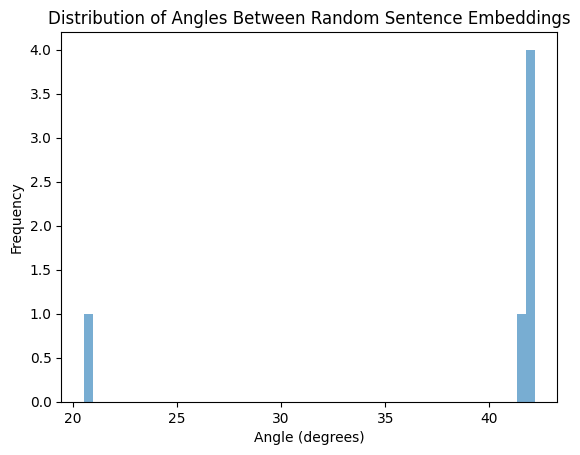

generated sentences
added query prefix
embedded sentences
Computed magnitudes for 100 sentences
Computed 4950 angles
Computed magnitudes for 100 sentences
Computed 4950 angles
Computed magnitudes for 100 sentences
Computed 4950 angles
calculated angles


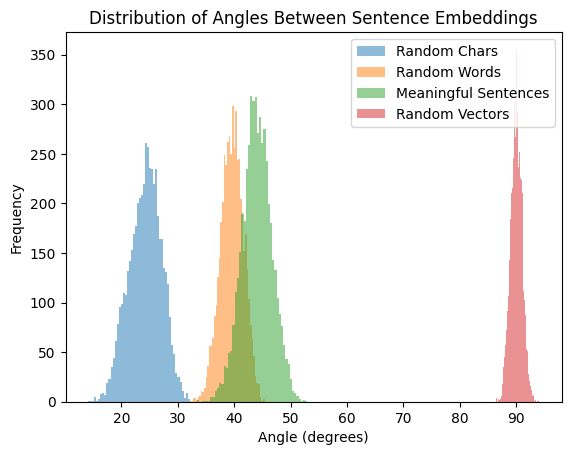

Mean:
Random Charachters: 24.23 degrees
Random Words: 39.61 degrees
Meaningful Sentences: 44.00 degrees
Random Vectors: 90.01 degrees 


Variance:
Random Charachters: 8.27 degrees
Random Words: 4.04 degrees
Meaningful Sentences: 6.93 degrees
Random Vectors: 1.07 degrees


In [34]:
# %%
import numpy as np
import matplotlib.pyplot as plt
from openai import OpenAI
import os
from dotenv import load_dotenv
import wikipedia
import bs4
import functools
from itertools import combinations
import time
import string
import random
import nltk
from collections import Counter

# %%
# Load NLTK data
nltk.download('brown')
nltk.download('punkt')

# %%
from nltk.corpus import brown
from nltk.probability import FreqDist
from nltk.tokenize import word_tokenize

load_dotenv()

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))


# %%
def create_random_chars(n, min_length=20, max_length=100):
    """
    Generate n sentences composed of random characters.
    Each sentence has a random length between min_length and max_length.
    """
    sentences = []
    for _ in range(n):
        length = random.randint(min_length, max_length)
        sentence = ''.join(random.choices(string.ascii_letters + string.digits + string.punctuation + ' ', k=length))
        sentences.append(sentence)
    return sentences

print(create_random_chars(3))

# %%
def create_random_words(n, min_words=6, max_words=18):
    """
    Generate n sentences composed of random English words based on frequency.
    Each sentence has a random number of words between min_words and max_words.
    """
    # Build frequency distribution from Brown Corpus
    words = brown.words()
    fdist = FreqDist(word.lower() for word in words if word.isalpha())
    vocabulary, frequencies = zip(*fdist.items())
    frequencies = np.array(frequencies, dtype=np.float64)
    probabilities = frequencies / frequencies.sum()
    
    sentences = []
    for _ in range(n):
        num_words = random.randint(min_words, max_words)
        selected_words = np.random.choice(vocabulary, size=num_words, replace=True, p=probabilities)
        sentence = ' '.join(selected_words)
        sentences.append(sentence)
    return sentences


print(create_random_words(3))

# %%
def create_random_meaningful_sentences(n):
    """
    Generate n grammatically correct and semantically meaningful sentences
    sampled randomly from the Brown Corpus.
    """
    # Extract all sentences from the Brown Corpus
    all_sentences = brown.sents()
    # Convert list of word tokens to sentences
    sentences = [' '.join(sentence) for sentence in all_sentences if len(sentence) >= 5]  # Filter short sentences
    # Sample n random sentences
    sampled_sentences = random.sample(sentences, n)
    return sampled_sentences

print(create_random_meaningful_sentences(3))

# %%
# def embed_text(text):
#     response = client.embeddings.create(
#         model="text-embedding-3-large",
#         input=text
#     )
    
#     return response.data[0].embedding

a = ["I am a sentence", "I am another sentence", "Louis was happy", "Ronalado plays socer"]

print(len(embed_text(a[0])))

def get_embeddings(text: list[str]):
    return [embed_text(sentence) for sentence in text]

b = get_embeddings(a)

def get_angles(embeddings):

    # Calculate magnitudes once
    magnitudes = np.array([np.linalg.norm(emb) for emb in embeddings])
    print(f"Computed magnitudes for {len(magnitudes)} sentences")
    
    # Compute pairwise dot products and angles directly
    angles = []
    for i in range(len(embeddings)):
        for j in range(i+1, len(embeddings)):
            dp = np.dot(embeddings[i], embeddings[j])
            # Calculate angle directly using dot product and magnitudes
            cos_theta = np.clip(dp / (magnitudes[i] * magnitudes[j]), -1.0, 1.0)
            angle = np.degrees(np.arccos(cos_theta))
            angles.append(angle)
            
    print(f"Computed {len(angles)} angles")
    
    return np.array(angles)

c = get_angles(b)

print(c)    
    
def plot_embedding_angles(angles):
    plt.hist(angles, bins=50, alpha=0.6)
    plt.title("Distribution of Angles Between Random Sentence Embeddings")
    plt.xlabel("Angle (degrees)")
    plt.ylabel("Frequency")
    plt.show()
    
plot_embedding_angles(c)

# %%
n = 100

# Generate random sentences
char_sentences = create_random_chars(n)
word_sentences = create_random_words(n)
meaningful_sentences = create_random_meaningful_sentences(n)
print("generated sentences")

# adding 'query:' to the start of all sentences

def add_query_prefix(sentences):
    return ["passage: " + sentence for sentence in sentences]

char_sentences = add_query_prefix(char_sentences)
word_sentences = add_query_prefix(word_sentences)
meaningful_sentences = add_query_prefix(meaningful_sentences)

print("added query prefix")

# Embed sentences
char_embeddings = get_embeddings(char_sentences)
word_embeddings = get_embeddings(word_sentences)
meaningful_embeddings = get_embeddings(meaningful_sentences)

print("embedded sentences")

# Calculate angles
char_angles = get_angles(char_embeddings)
word_angles = get_angles(word_embeddings)
meaningful_angles = get_angles(meaningful_embeddings)

print("calculated angles")

# %%
# Generate random vectors and calculate angles
random_vectors = np.random.randn(n, 3072)
random_embeddings = random_vectors / np.linalg.norm(random_vectors, axis=1, keepdims=True)
random_angles = []
for i in range(n):
    for j in range(i + 1, n):
        angle = np.degrees(np.arccos(np.clip(np.dot(random_embeddings[i], random_embeddings[j]), -1.0, 1.0)))
        random_angles.append(angle)

# Plot distributions
plt.hist(char_angles, bins=50, alpha=0.5, label='Random Chars')
plt.hist(word_angles, bins=50, alpha=0.5, label='Random Words')
plt.hist(meaningful_angles, bins=50, alpha=0.5, label='Meaningful Sentences')
plt.hist(random_angles, bins=50, alpha=0.5, label='Random Vectors')
plt.title("Distribution of Angles Between Sentence Embeddings")
plt.xlabel("Angle (degrees)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# %%
# printing mean and variance

print('Mean:')
print(f"Random Charachters: {np.mean(char_angles):.2f} degrees")
print(f"Random Words: {np.mean(word_angles):.2f} degrees")
print(f"Meaningful Sentences: {np.mean(meaningful_angles):.2f} degrees")
print(f"Random Vectors: {np.mean(random_angles):.2f} degrees \n\n")

print('Variance:')
print(f"Random Charachters: {np.var(char_angles):.2f} degrees")
print(f"Random Words: {np.var(word_angles):.2f} degrees")
print(f"Meaningful Sentences: {np.var(meaningful_angles):.2f} degrees")
print(f"Random Vectors: {np.var(random_angles):.2f} degrees")





In [35]:
print(char_sentences[0])

passage: ,Ch~&LF.=V]]aQ#?EC+MJ*<B =QaaqS[i1M?*>jI:


In [33]:
def create_random_meaningful_sentences(n):
    """
    Generate n grammatically correct and semantically meaningful sentences
    sampled randomly from the Brown Corpus.
    """
    # Extract all sentences from the Brown Corpus
    all_sentences = brown.sents()
    # Convert list of word tokens to sentences
    sentences = [' '.join(sentence) for sentence in all_sentences if len(sentence) >= 5]  # Filter short sentences
    # Sample n random sentences
    sampled_sentences = random.sample(sentences, n)
    return sampled_sentences

a = create_random_meaningful_sentences(1)

b = create_random_meaningful_sentences(1)

print(a, '\n', b)

lst = [embed_text(a[0]), embed_text(b[0])]

get_angles(lst)

['Every single problem touched on thus far is related to good marketing planning .'] 
 ['But for all his erudite confidence , Sergeant Early was right out of the Garryowen mold .']
Computed magnitudes for 2 sentences
Computed 1 angles


array([43.01209182])

# Mathematical Formulations for Bias Parameters

### 1. **Risk Aversion (λ or γ):**
   - Formula: $U(x) = \frac{x^{1-\gamma}}{1-\gamma}, \text{ if } \gamma \neq 1$
   - Description: Utility of wealth $x$ under risk preferences, where $ \gamma > 0$ indicates risk aversion.

### 2. **Loss Aversion (θ or λ):**
   - Formula: 
     $$
     V(x) = \begin{cases} 
     x & \text{if } x \geq 0 \\
     -\lambda x & \text{if } x < 0
     \end{cases}
     $$
   - Description: Gains are valued linearly, but losses are amplified by a factor $\lambda > 1$.

### 3. **Social Comparison (ρ):**
   - Formula: $U(x_i, x_j) = x_i - \rho (x_j - x_i), \text{ for } x_j > x_i$
   - Description: Utility $U$ decreases with negative social comparison.

### 4. **Fairness and Reciprocity (ξ):**
   - Formula: $U = x_i - \xi \max(0, x_j - x_i)$
   - Description: Utility reduces with perceived unfairness.

### 5. **Confirmation Bias (ζ):**
   - Formula: $P(H|E) = \zeta \cdot \frac{P(E|H)P(H)}{P(E)}$
   - Description: Prior belief $P(H)$ is amplified by a factor $\zeta > 1$.

### 6. **Habit Formation (η):**
   - Formula: $U_t = u(c_t) + \eta \cdot U_{t-1}$
   - Description: Current utility $U_t$ depends on past utility.

### 7. **Overconfidence (ω):**
   - Formula: $P(success) = \omega \cdot \text{true probability}, \omega > 1$
   - Description: Perceived success probability exceeds true likelihood.

### 8. **Altruism (δ):**
   - Formula: $U_i = u(c_i) + \delta \cdot u(c_j)$
   - Description: Utility includes benefits to others.

### 9. **Status Quo Bias (ψ):**
   - Formula: $U = u(x) + \psi \cdot u(\text{status quo})$
   - Description: Preference for current state over alternatives.

### 10. **Sunk Cost Fallacy (φ):**
   - Formula: $U = u(x) + \phi \cdot \text{sunk cost}$
   - Description: Decision-making incorporates irrecoverable costs.

### 11. **Temporal Consistency/Hyperbolic Discounting (β, δ):**
   - Formula: $U = \sum_{t=0}^T \frac{u(c_t)}{(1 + \beta t)^\delta}$
   - Description: Future rewards are discounted non-linearly.

### 12. **Ambiguity Aversion (μ):**
   - Formula: $U = \mu \cdot P(x) + (1 - \mu) \cdot \text{Ambiguity Bias}$
   - Description: Weight $\mu$ reduces the impact of ambiguous probabilities.

### 13. **Cognitive Load (κ):**
   - Formula: $U = u(c) - \kappa \cdot \text{Cognitive Effort}$
   - Description: Utility decreases with cognitive strain.

### 14. **Inequity Aversion (α, β in Fehr-Schmidt model):**
   - Formula: 
     $$
     U_i = x_i - \alpha \sum_{j \neq i} \max(x_j - x_i, 0) - \beta \sum_{j \neq i} \max(x_i - x_j, 0)
     $$
   - Description: Utility diminishes with perceived inequity, where $\alpha, \beta > 0$.